# Machine Learning Wrapup - Regression

## Libraries

In [1]:
# DATA MANIPULATION
import pandas as pd
pd.set_option("display.max_columns", None)
import numpy as np
import datetime

# STATS
from statsmodels.graphics.gofplots import qqplot

# DATA VISUALISATION
import matplotlib.pyplot as plt
import seaborn as sns

# ML
## PREPROC
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import RobustScaler, StandardScaler, MinMaxScaler
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
# METRICS
from sklearn.metrics import r2_score, mean_squared_error
## MODEL
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, SGDRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

## Airbnb Prices (Regression)

### Dataset

#### Loading

In [2]:
airbnb_asheville = "https://wagon-public-datasets.s3.amazonaws.com/data-science-images/05-ML/Reboot-2/asheville_airbnb.csv"
airbnb_nyc = "https://wagon-public-datasets.s3.amazonaws.com/data-science-images/05-ML/Reboot-2/new_york.csv"

In [3]:
df = pd.read_csv(airbnb_asheville, index_col=0)
df.head()

,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms_text,bedrooms,beds,price,minimum_nights,number_of_reviews,review_scores_rating,availability_365,instant_bookable,id,listing_url,scrape_id,last_scraped,name,description
0,28801,35.60670,-82.55563,Entire rental unit,Entire home/apt,2,1 bath,1.0,1.0,$120.00,30,90,4.50,285,f,108061,https://www.airbnb.com/rooms/108061,20220611041116,2022-06-11,Walk to stores/parks/downtown. Fenced yard/Pet...,Walk to town in ten minutes! Monthly rental in...
1,28806,35.57864,-82.59578,Entire guesthouse,Entire home/apt,2,1 bath,1.0,1.0,$100.00,1,359,4.58,179,t,155305,https://www.airbnb.com/rooms/155305,20220611041116,2022-06-11,Cottage! BonPaul + Sharky's Hostel,<b>The space</b><br />Private cottage located ...
2,28806,35.57864,-82.59578,Private room in home,Private room,2,2.5 shared baths,1.0,1.0,$66.00,1,67,4.52,0,t,156805,https://www.airbnb.com/rooms/156805,20220611041116,2022-06-11,"Private Room ""Ader"" at BPS Hostel",<b>The space</b><br />Private Rooms at Bon Pau...
3,28806,35.57864,-82.59578,Shared room in hostel,Shared room,1,2.5 shared baths,1.0,6.0,$33.00,1,306,4.71,199,t,156926,https://www.airbnb.com/rooms/156926,20220611041116,2022-06-11,"Mixed Dorm ""Top Bunk #1"" at BPS Hostel",This is a top bunk in the mixed dorm room<br /...
4,28806,35.57808,-82.63689,Private room in home,Private room,2,1 private bath,1.0,1.0,$45.00,2,51,4.98,78,f,197263,https://www.airbnb.com/rooms/197263,20220611041116,2022-06-11,Tranquil Room & Private Bath,"This is a comfy, peaceful and clean room with ..."


#### Basic info

In [4]:
df.shape

(2856, 21)

In [5]:
df.dtypes

neighbourhood_cleansed      int64
latitude                  float64
longitude                 float64
property_type              object
room_type                  object
accommodates                int64
bathrooms_text             object
bedrooms                  float64
beds                      float64
price                      object
minimum_nights              int64
number_of_reviews           int64
review_scores_rating      float64
availability_365            int64
instant_bookable           object
id                          int64
listing_url                object
scrape_id                   int64
last_scraped               object
name                       object
description                object
dtype: object

#### Pre-cleaning

##### Duplicated

In [6]:
df.duplicated().sum()

0

In [7]:
df = df.drop_duplicates()

##### Price as a float

In [8]:
# converting price from string to float
df["price"] = df["price"].str.replace("$","").str.replace(",","").astype(float)

/var/folders/6p/s5dyg_x13_zbgfd_xsyg3s7c0000gn/T/ipykernel_24086/39868305.py:2: FutureWarning: The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
  df["price"] = df["price"].str.replace("$","").str.replace(",","").astype(float)


<Axes: xlabel='price', ylabel='Count'>

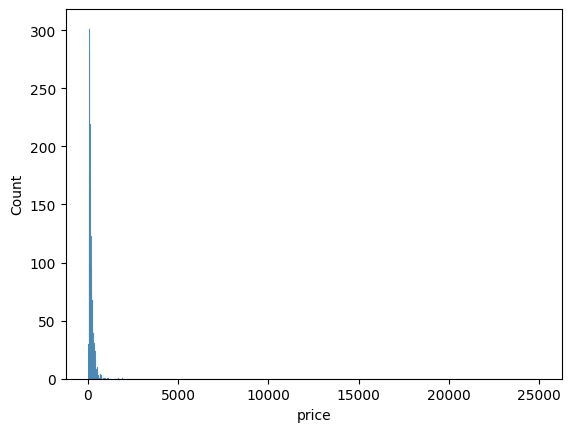

In [9]:
sns.histplot(df["price"])

##### Affordable accommodations

In [10]:
reasonable = (df["price"]>50) & (df["price"]< 1500)

In [11]:
df = df[reasonable].copy()
df.shape

(2746, 21)

<Axes: xlabel='price', ylabel='Count'>

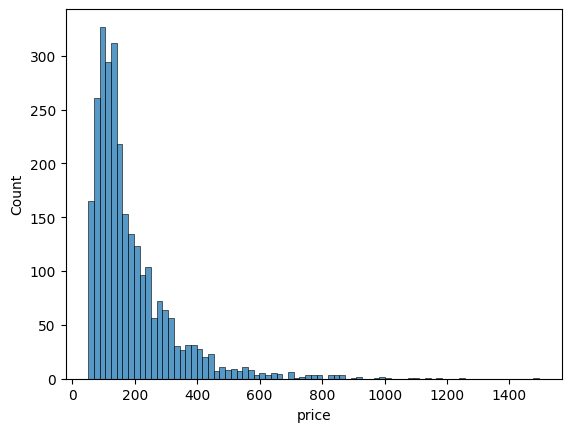

In [12]:
sns.histplot(df["price"])

In [13]:
df.dtypes.value_counts()

object     8
int64      7
float64    6
dtype: int64

##### Missing values - First glimpse

In [14]:
df.isna().sum().sort_values(ascending=False)

review_scores_rating      179
bedrooms                  145
beds                       18
description                 7
name                        0
last_scraped                0
scrape_id                   0
listing_url                 0
id                          0
instant_bookable            0
availability_365            0
neighbourhood_cleansed      0
number_of_reviews           0
latitude                    0
price                       0
bathrooms_text              0
accommodates                0
room_type                   0
property_type               0
longitude                   0
minimum_nights              0
dtype: int64

In [15]:
df.isna().mean().sort_values(ascending=False)

review_scores_rating      0.065186
bedrooms                  0.052804
beds                      0.006555
description               0.002549
name                      0.000000
last_scraped              0.000000
scrape_id                 0.000000
listing_url               0.000000
id                        0.000000
instant_bookable          0.000000
availability_365          0.000000
neighbourhood_cleansed    0.000000
number_of_reviews         0.000000
latitude                  0.000000
price                     0.000000
bathrooms_text            0.000000
accommodates              0.000000
room_type                 0.000000
property_type             0.000000
longitude                 0.000000
minimum_nights            0.000000
dtype: float64

In [16]:
# Replace missing descriptions with empty strings
df["description"] = df["description"].fillna("")

In [17]:
# review_scores_rating - we will use the numerical pipeline to impute them
df["review_scores_rating"]

0       4.50
1       4.58
2       4.52
5       4.87
6       4.66
        ... 
2850    4.76
2852    4.79
2853    5.00
2854    4.94
2855    4.97
Name: review_scores_rating, Length: 2746, dtype: float64

In [18]:
# bedrooms - we will use the numerical pipeline to impute them
df["bedrooms"].value_counts(dropna=False)

1.0    1182
2.0     720
3.0     446
4.0     176
NaN     145
5.0      47
6.0      20
7.0       8
8.0       2
Name: bedrooms, dtype: int64

In [19]:
# beds - we will use the numerical pipeline to impute them
df["beds"].value_counts(dropna=False)

1.0     924
2.0     810
3.0     435
4.0     250
5.0     129
6.0      83
7.0      46
8.0      18
NaN      18
11.0     10
9.0       7
12.0      6
10.0      5
15.0      2
13.0      1
21.0      1
16.0      1
Name: beds, dtype: int64

#### Selecting features manually

In [20]:
df.head()

,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms_text,bedrooms,beds,price,minimum_nights,number_of_reviews,review_scores_rating,availability_365,instant_bookable,id,listing_url,scrape_id,last_scraped,name,description
0,28801,35.60670,-82.55563,Entire rental unit,Entire home/apt,2,1 bath,1.0,1.0,120.0,30,90,4.50,285,f,108061,https://www.airbnb.com/rooms/108061,20220611041116,2022-06-11,Walk to stores/parks/downtown. Fenced yard/Pet...,Walk to town in ten minutes! Monthly rental in...
1,28806,35.57864,-82.59578,Entire guesthouse,Entire home/apt,2,1 bath,1.0,1.0,100.0,1,359,4.58,179,t,155305,https://www.airbnb.com/rooms/155305,20220611041116,2022-06-11,Cottage! BonPaul + Sharky's Hostel,<b>The space</b><br />Private cottage located ...
2,28806,35.57864,-82.59578,Private room in home,Private room,2,2.5 shared baths,1.0,1.0,66.0,1,67,4.52,0,t,156805,https://www.airbnb.com/rooms/156805,20220611041116,2022-06-11,"Private Room ""Ader"" at BPS Hostel",<b>The space</b><br />Private Rooms at Bon Pau...
5,28804,35.61856,-82.55276,Entire guest suite,Entire home/apt,4,1 bath,1.0,2.0,134.0,30,58,4.87,314,f,209068,https://www.airbnb.com/rooms/209068,20220611041116,2022-06-11,Terrace Cottage,Located in one of Asheville's oldest historic ...
6,28805,35.59635,-82.50655,Private room in cabin,Private room,2,1 shared bath,1.0,1.0,68.0,7,57,4.66,44,f,246315,https://www.airbnb.com/rooms/246315,20220611041116,2022-06-11,Asheville Dreamer's Cabin,"Hi there,<br />I am usually here half of each ..."


In [21]:
df["property_type"].value_counts(dropna=True)

Entire home                          931
Entire rental unit                   359
Entire guest suite                   357
Private room in home                 192
Entire condo                         168
Entire cabin                         104
Entire cottage                       103
Entire guesthouse                    101
Entire bungalow                       74
Entire townhouse                      53
Entire loft                           41
Private room in guest suite           35
Tiny home                             30
Private room in bed and breakfast     25
Private room in bungalow              18
Room in boutique hotel                15
Entire chalet                         14
Room in bed and breakfast             13
Entire vacation home                  13
Private room in rental unit           12
Farm stay                             11
Camper/RV                             10
Entire place                           9
Private room                           9
Private room in 

In [22]:
df["room_type"].value_counts(dropna=True)

Entire home/apt    2403
Private room        327
Hotel room           15
Shared room           1
Name: room_type, dtype: int64

In [23]:
df["bathrooms_text"].value_counts()

1 bath              1402
2 baths              567
1 private bath       205
2.5 baths            139
3 baths              134
1.5 baths             97
1 shared bath         62
3.5 baths             51
4 baths               38
4.5 baths             10
1.5 shared baths       9
2 shared baths         9
5 baths                8
6 baths                5
5.5 baths              3
2.5 shared baths       2
Half-bath              2
0 shared baths         1
0 baths                1
7 baths                1
Name: bathrooms_text, dtype: int64

In [24]:
import re

def extract_number(text):
    if text and type(text)==str:
        match = re.search(r'\d+(\.\d+)?', text)
        return float(match.group()) if match else None
    else:
        return None

In [25]:
df["bathrooms_text"] = df["bathrooms_text"].apply(extract_number)

In [26]:
df["instant_bookable"] = df["instant_bookable"].map({"t":True, "f":False})

In [27]:
# plt.figure(figsize=(10,10))
# sns.heatmap(df.corr(), annot = True, cmap = "PuRd")

In [28]:
df.head()

,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms_text,bedrooms,beds,price,minimum_nights,number_of_reviews,review_scores_rating,availability_365,instant_bookable,id,listing_url,scrape_id,last_scraped,name,description
0,28801,35.60670,-82.55563,Entire rental unit,Entire home/apt,2,1.0,1.0,1.0,120.0,30,90,4.50,285,False,108061,https://www.airbnb.com/rooms/108061,20220611041116,2022-06-11,Walk to stores/parks/downtown. Fenced yard/Pet...,Walk to town in ten minutes! Monthly rental in...
1,28806,35.57864,-82.59578,Entire guesthouse,Entire home/apt,2,1.0,1.0,1.0,100.0,1,359,4.58,179,True,155305,https://www.airbnb.com/rooms/155305,20220611041116,2022-06-11,Cottage! BonPaul + Sharky's Hostel,<b>The space</b><br />Private cottage located ...
2,28806,35.57864,-82.59578,Private room in home,Private room,2,2.5,1.0,1.0,66.0,1,67,4.52,0,True,156805,https://www.airbnb.com/rooms/156805,20220611041116,2022-06-11,"Private Room ""Ader"" at BPS Hostel",<b>The space</b><br />Private Rooms at Bon Pau...
5,28804,35.61856,-82.55276,Entire guest suite,Entire home/apt,4,1.0,1.0,2.0,134.0,30,58,4.87,314,False,209068,https://www.airbnb.com/rooms/209068,20220611041116,2022-06-11,Terrace Cottage,Located in one of Asheville's oldest historic ...
6,28805,35.59635,-82.50655,Private room in cabin,Private room,2,1.0,1.0,1.0,68.0,7,57,4.66,44,False,246315,https://www.airbnb.com/rooms/246315,20220611041116,2022-06-11,Asheville Dreamer's Cabin,"Hi there,<br />I am usually here half of each ..."


In [29]:
df["neigh"] = df["neighbourhood_cleansed"].map({28806:"A",
                                 28801:"B",
                                 28803:"C",
                                 28804:"D",
                                 28805:"E",
                                 28704:"F",
                                 28715:"G",
                                 28732:"H"})

In [30]:
selected_features = ["neigh", "room_type", "accommodates", "bedrooms", "beds",
                     "price", "minimum_nights", "number_of_reviews",
                     "review_scores_rating", "instant_bookable"]

In [31]:
df = df[selected_features].copy()

In [32]:
# delete the only row with shared room
df = df[~(df["room_type"]=="Shared room")]

In [33]:
y = df["price"]
X = df.drop(columns="price")

#### Pre-cleaning in one single function

In [34]:
def df_pre_cleaning(df:pd.DataFrame, selected_features:list)-> pd.DataFrame:
    # Let's work on a copy of df
    df_copy = df.copy()
    # Convert price from string to float
    df_copy["price"] = df_copy["price"].str.replace("$", "", regex = True).str.replace(",", "", regex = True).astype(float)
    # Relevant features only
    df_copy = df_copy[selected_features]
    # Bathrooms
    def extract_number(text):
        if text and type(text)==str:
            match = re.search(r'\d+(\.\d+)?', text)
            return float(match.group()) if match else None
        else:
            return None
    df_copy["bathrooms_text"] = df_copy["bathrooms_text"].apply(extract_number)
    # Neighborhoods
    df_copy["neigh"] = df_copy["neighbourhood_cleansed"].map({28806:"A",
                                 28801:"B",
                                 28803:"C",
                                 28804:"D",
                                 28805:"E",
                                 28704:"F",
                                 28715:"G",
                                 28732:"H"})
    
    # delete the only row with shared room
    df_copy = df_copy[~(df_copy["room_type"]=="Shared room")]
    # Instant bookable
    df_copy["instant_bookable"] = df_copy["instant_bookable"].map({'t':True,'f':False})
    
    return df_copy

### Preprocessing

In [35]:
df.to_csv("airbnb_a_bit_processed.csv")

#### Scaling the numerical features

In [36]:
X.dtypes

neigh                    object
room_type                object
accommodates              int64
bedrooms                float64
beds                    float64
minimum_nights            int64
number_of_reviews         int64
review_scores_rating    float64
instant_bookable           bool
dtype: object

In [37]:
X_num = X.select_dtypes(include="number")
X_num.dtypes

accommodates              int64
bedrooms                float64
beds                    float64
minimum_nights            int64
number_of_reviews         int64
review_scores_rating    float64
dtype: object

In [38]:
X_num.columns

Index(['accommodates', 'bedrooms', 'beds', 'minimum_nights',
       'number_of_reviews', 'review_scores_rating'],
      dtype='object')

--------------------------------------------------


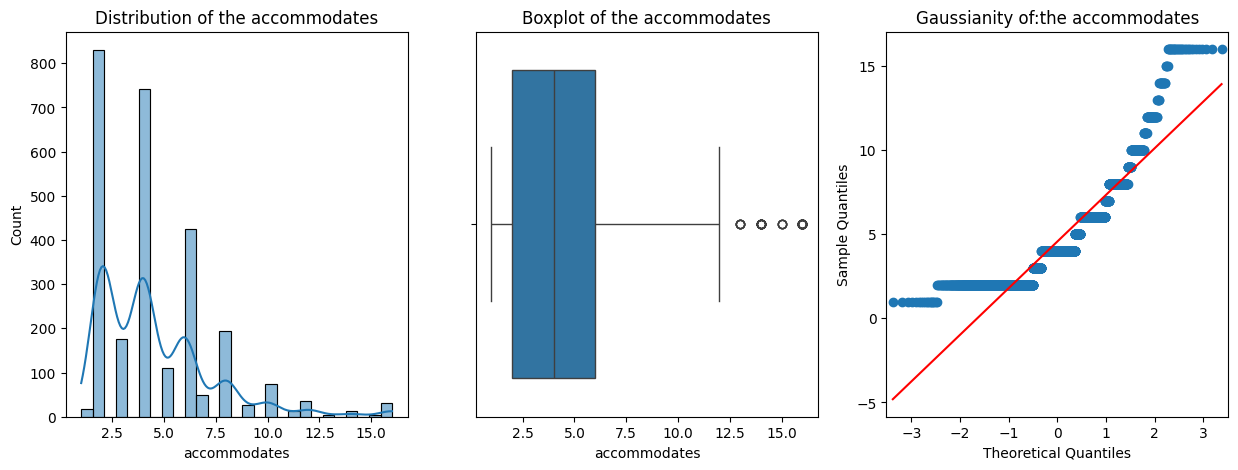

--------------------------------------------------


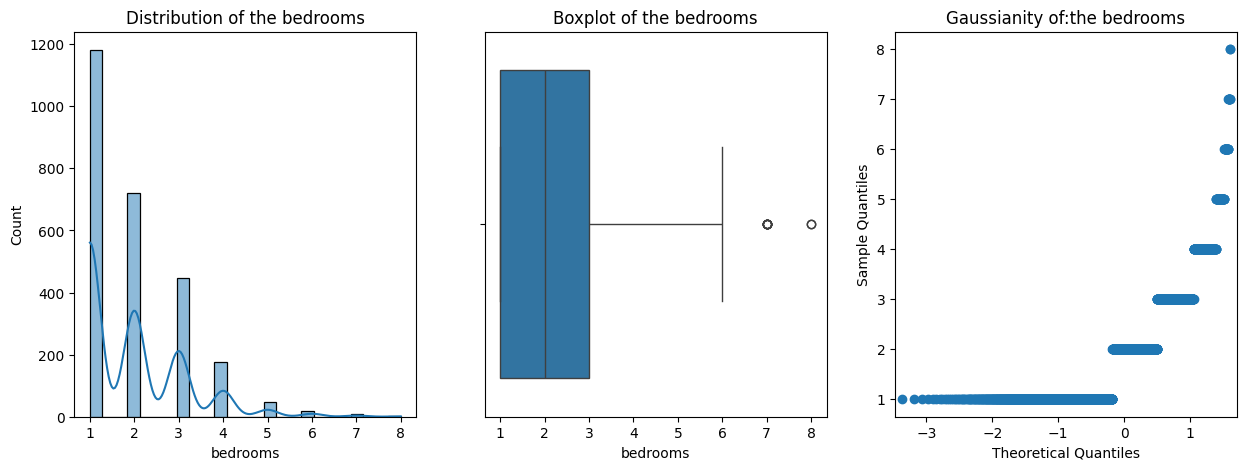

--------------------------------------------------


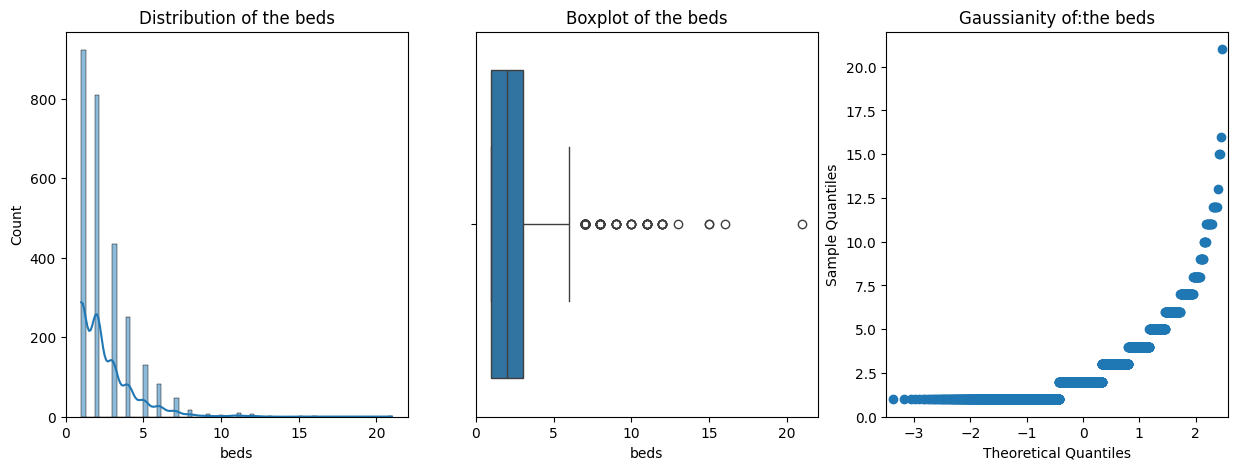

--------------------------------------------------


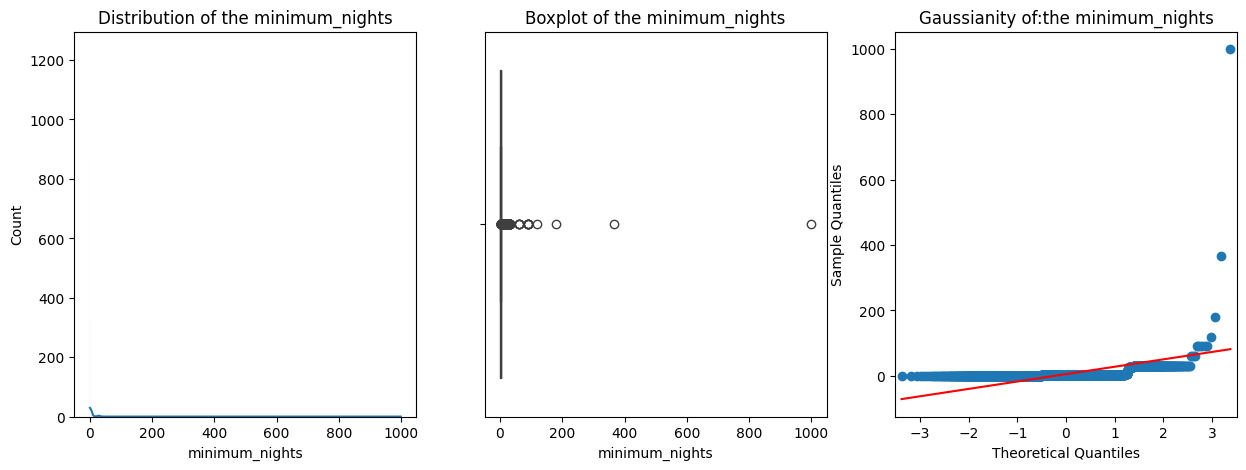

--------------------------------------------------


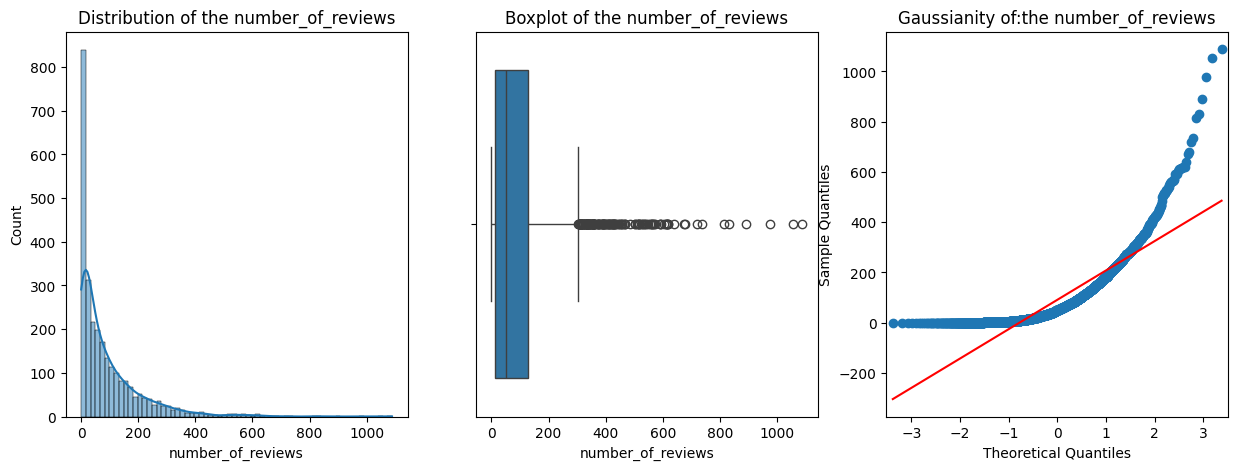

--------------------------------------------------


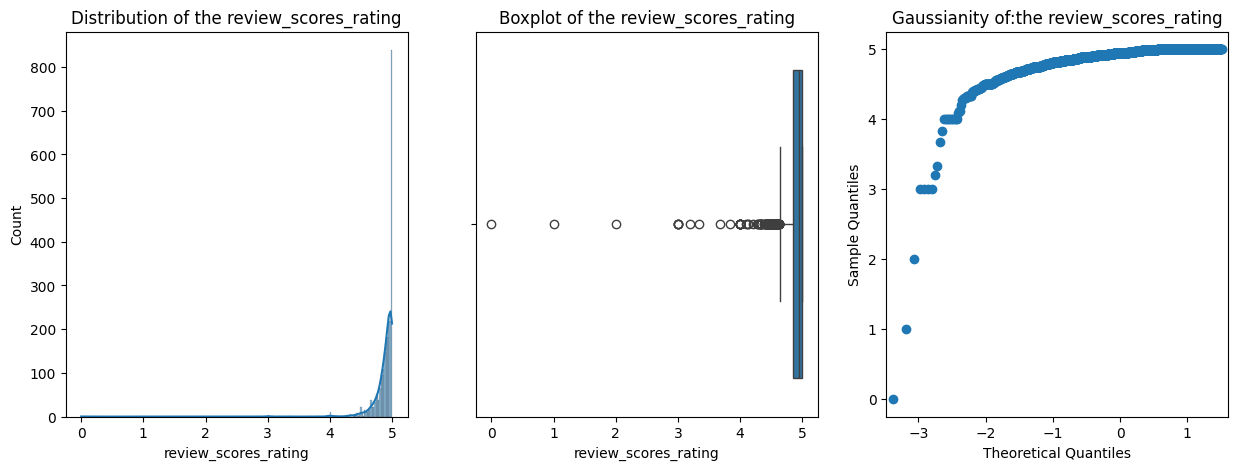

In [39]:
for variable in list(X_num.columns):
    print("-"*50)

    fig, ax = plt.subplots(1,3,figsize=(15,5))

    ax[0].set_title(f"Distribution of the {variable}")
    sns.histplot(data = X_num, x = f"{variable}", kde=True, ax = ax[0])

    ax[1].set_title(f"Boxplot of the {variable}")
    sns.boxplot(data = X_num, x = f"{variable}", ax=ax[1])

    ax[2].set_title(f"Gaussianity of:the {variable}")
    qqplot(X_num[f"{variable}"],line='s',ax=ax[2]);
    
    plt.show();

In [40]:
robust_features = ["minimum_nights", "number_of_reviews", "review_scores_rating"]
standard_features = []
minmax_features = ["accommodates", "bedrooms", "beds"]

In [41]:
scalers = ColumnTransformer([
    ("rob", RobustScaler(), robust_features), # Robust
    ("std", StandardScaler(), standard_features), # Std
    ("mm", MinMaxScaler(), minmax_features), # MinMax
])

numerical_pipeline = Pipeline([
    ("imputer", KNNImputer()),
    ("scalers", scalers)
])

numerical_pipeline

Pipeline(steps=[('imputer', KNNImputer()),
                ('scalers',
                 ColumnTransformer(transformers=[('rob', RobustScaler(),
                                                  ['minimum_nights',
                                                   'number_of_reviews',
                                                   'review_scores_rating']),
                                                 ('std', StandardScaler(), []),
                                                 ('mm', MinMaxScaler(),
                                                  ['accommodates', 'bedrooms',
                                                   'beds'])]))])

#### Encoding the categorical features

In [42]:
X_cat = X.select_dtypes(exclude="number")
X_cat.dtypes

neigh               object
room_type           object
instant_bookable      bool
dtype: object

In [43]:
for feature in list(X_cat.columns):
    print("-"*50)
    print(f"The different values for {feature} are:")
    display(X_cat[feature].value_counts(dropna=False))

--------------------------------------------------
The different values for neigh are:


A    764
B    621
C    377
D    373
E    265
F    191
G     81
H     73
Name: neigh, dtype: int64

--------------------------------------------------
The different values for room_type are:


Entire home/apt    2403
Private room        327
Hotel room           15
Name: room_type, dtype: int64

--------------------------------------------------
The different values for instant_bookable are:


True     1601
False    1144
Name: instant_bookable, dtype: int64

In [44]:
ordinal_features = ["room_type"]
onehot_features = ["neigh"]

In [45]:
encoders = ColumnTransformer([
    ("ord", OrdinalEncoder(), ordinal_features), # Ordinal
    ("one_hot", OneHotEncoder(sparse_output=False, drop="if_binary", handle_unknown="ignore") ,onehot_features) # OHE
], remainder="passthrough")

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoders", encoders)
])

categorical_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoders',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ord', OrdinalEncoder(),
                                                  ['room_type']),
                                                 ('one_hot',
                                                  OneHotEncoder(drop='if_binary',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['neigh'])]))])

#### Final Preprocessor

In [46]:
preprocessor = ColumnTransformer([
    ("num_pipeline", numerical_pipeline, make_column_selector(dtype_include="number")), # num_features
    ("cat_pipeline", categorical_pipeline, make_column_selector(dtype_exclude="number")) # cat_features
], remainder="passthrough").set_output(transform="pandas")

preprocessor

ColumnTransformer(remainder='passthrough',
                  transformers=[('num_pipeline',
                                 Pipeline(steps=[('imputer', KNNImputer()),
                                                 ('scalers',
                                                  ColumnTransformer(transformers=[('rob',
                                                                                   RobustScaler(),
                                                                                   ['minimum_nights',
                                                                                    'number_of_reviews',
                                                                                    'review_scores_rating']),
                                                                                  ('std',
                                                                                   StandardScaler(),
                                                                                   []),
                                                                                  ('mm',
                                                                                   MinMaxScaler(),
                                                                                   ['accommodates',
                                                                                    'bedrooms',
                                                                                    'beds'])]))]),
                                 <sklearn.compose._c...
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoders',
                                                  ColumnTransformer(remainder='passthrough',
                                                                    transformers=[('ord',
                                                                                   OrdinalEncoder(),
                                                                                   ['room_type']),
                                                                                  ('one_hot',
                                                                                   OneHotEncoder(drop='if_binary',
                                                                                                 handle_unknown='ignore',
                                                                                                 sparse_output=False),
                                                                                   ['neigh'])]))]),
                                 <sklearn.compose._column_transformer.make_column_selector object at 0x34df64800>)])

### Modeling

#### Train-Test Split

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25)

In [48]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((2058, 9), (687, 9), (2058,), (687,))

#### Transform data

In [49]:
preprocessor.fit(X_train)

ColumnTransformer(remainder='passthrough',
                  transformers=[('num_pipeline',
                                 Pipeline(steps=[('imputer', KNNImputer()),
                                                 ('scalers',
                                                  ColumnTransformer(transformers=[('rob',
                                                                                   RobustScaler(),
                                                                                   ['minimum_nights',
                                                                                    'number_of_reviews',
                                                                                    'review_scores_rating']),
                                                                                  ('std',
                                                                                   StandardScaler(),
                                                                                   []),
                                                                                  ('mm',
                                                                                   MinMaxScaler(),
                                                                                   ['accommodates',
                                                                                    'bedrooms',
                                                                                    'beds'])]))]),
                                 <sklearn.compose._c...
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoders',
                                                  ColumnTransformer(remainder='passthrough',
                                                                    transformers=[('ord',
                                                                                   OrdinalEncoder(),
                                                                                   ['room_type']),
                                                                                  ('one_hot',
                                                                                   OneHotEncoder(drop='if_binary',
                                                                                                 handle_unknown='ignore',
                                                                                                 sparse_output=False),
                                                                                   ['neigh'])]))]),
                                 <sklearn.compose._column_transformer.make_column_selector object at 0x34df64800>)])

In [50]:
X_train_preproc = preprocessor.transform(X_train)
X_test_preproc = preprocessor.transform(X_test)

#### Linear Regression

In [51]:
linreg = LinearRegression()
linreg.fit(X_train_preproc, y_train)
linreg.score(X_test_preproc, y_test)

0.5536530815347466

In [52]:
linreg_cv = cross_validate(LinearRegression(), X_train_preproc, y_train, 
                           cv = 5, 
                           scoring=["r2", "neg_mean_squared_error"],
                           n_jobs=-1)

In [53]:
linreg_cv.keys()

dict_keys(['fit_time', 'score_time', 'test_r2', 'test_neg_mean_squared_error'])

In [54]:
linreg_cv["test_r2"].mean()

0.39889619758717815

In [55]:
np.sqrt(-linreg_cv["test_neg_mean_squared_error"]).mean()

106.61433794101364

#### Trying all the models!

In [56]:
models = [LinearRegression(),
         Ridge(),
         Lasso(),
         ElasticNet(),
         SGDRegressor(),
         KNeighborsRegressor(),
         SVR(kernel="rbf"),
         DecisionTreeRegressor(),
         RandomForestRegressor(),
         AdaBoostRegressor(),
         GradientBoostingRegressor()]

In [57]:
models_names = ["linear_regression",
                "ridge",
                "lasso",
                "elastic_net",
                "sgd_regressor",
                "kneighbors_regressor",
                "SVR_rbf",
                "decision_tree_regressor",
                "random_forest_regressor",
                "ada_boost_regressor",
                "gradient_boosting_regressor"
]

In [58]:
%%time
list_of_scores = []
list_of_rmse = []

for model in models:
    pipelined_model = make_pipeline(preprocessor, model)
    temp_cv = cross_validate(pipelined_model, X_train, y_train, 
                           cv = 5, 
                           scoring=["r2", "neg_mean_squared_error"],
                           n_jobs=-1)
    temp_r2 = temp_cv["test_r2"].mean()
    temp_rmse = np.sqrt(-temp_cv["test_neg_mean_squared_error"]).mean()
    list_of_scores.append(temp_r2)
    list_of_rmse.append(temp_rmse)

CPU times: user 55.7 ms, sys: 10.1 ms, total: 65.7 ms
Wall time: 3.31 s


In [59]:
airbnb_regressions_results = pd.DataFrame({"model_name":models_names,
                                          "r2":list_of_scores,
                                          "rmse":list_of_rmse})

In [60]:
airbnb_regressions_results.sort_values(by="r2",ascending=False)

,model_name,r2,rmse
8,random_forest_regressor,5.683780e-01,9.083969e+01
10,gradient_boosting_regressor,5.634784e-01,9.125771e+01
0,linear_regression,3.962690e-01,1.068532e+02
1,ridge,3.952652e-01,1.069233e+02
2,lasso,3.949932e-01,1.070168e+02
5,kneighbors_regressor,3.788992e-01,1.092430e+02
9,ada_boost_regressor,2.651708e-01,1.181942e+02
7,decision_tree_regressor,1.697701e-01,1.244984e+02
3,elastic_net,2.567370e-02,1.363307e+02
6,SVR_rbf,-5.960787e-02,1.426041e+02


In [61]:
airbnb_regressions_results.sort_values(by="rmse",ascending=True)

,model_name,r2,rmse
8,random_forest_regressor,5.683780e-01,9.083969e+01
10,gradient_boosting_regressor,5.634784e-01,9.125771e+01
0,linear_regression,3.962690e-01,1.068532e+02
1,ridge,3.952652e-01,1.069233e+02
2,lasso,3.949932e-01,1.070168e+02
5,kneighbors_regressor,3.788992e-01,1.092430e+02
9,ada_boost_regressor,2.651708e-01,1.181942e+02
7,decision_tree_regressor,1.697701e-01,1.244984e+02
3,elastic_net,2.567370e-02,1.363307e+02
6,SVR_rbf,-5.960787e-02,1.426041e+02
